<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/Deep%20Learning/Pytorch/9_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from tqdm import tqdm

import torchvision
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchmetrics

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.7 MB/s eta 0:00:00


In [ ]:
batch_size = 60
train_dataset = datasets.CIFAR10(root = 'dataset/',
                                 download=True,
                                 train = True,
                                 transform = transforms.ToTensor())

train_loader = DataLoader(dataset = train_dataset,
                          batch_size= batch_size,
                          shuffle = True)

test_dataset = datasets.CIFAR10(root = 'dataset/',
                                 download=True,
                                 train = False,
                                 transform = transforms.ToTensor())
test_loader = DataLoader(dataset = test_dataset,
                          batch_size= batch_size,
                          shuffle = True)

100%|██████████| 170M/170M [00:10<00:00, 16.2MB/s]


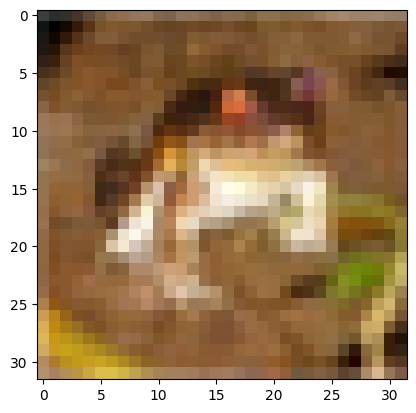

In [ ]:
#
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

# get some random training images
dataiter = iter(train_dataset)
images, labels = next(dataiter)
labels
# show images
imshow(torchvision.utils.make_grid(images))


In [ ]:
class CIFAR10(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CIFAR10, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CIFAR10(in_channels=3, num_classes=10).to(device)
print(model)

CIFAR10(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)


In [ ]:
# train the CNN model

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
  print(f"Epoch {epoch + 1}/ {num_epochs}")

  for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
    data = data.to(device)
    targets =  targets.to(device)
    scores = model(data)
    loss = criterion(scores, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 1/ 10


100%|██████████| 834/834 [02:09<00:00,  6.43it/s]


Epoch 2/ 10


100%|██████████| 834/834 [02:11<00:00,  6.34it/s]


Epoch 3/ 10


...

100%|██████████| 834/834 [02:08<00:00,  6.50it/s]


Epoch 9/ 10


100%|██████████| 834/834 [02:07<00:00,  6.53it/s]


Epoch 10/ 10


100%|██████████| 834/834 [02:06<00:00,  6.58it/s]


In [ ]:
from torchmetrics.classification import Accuracy, Precision, Recall

# Set up of multiclass accuracy metric
acc = Accuracy(task="multiclass",num_classes=10)
precision = Precision(task="multiclass", num_classes=10)
recall = Recall(task="multiclass", num_classes=10)


# Iterate over the dataset batches
model.eval()
with torch.no_grad():
   for images, labels in test_loader: # Changed dataloader_test to test_loader
       images = images.to(device) # Move images to device
       labels = labels.to(device) # Move labels to device
       # Get predicted probabilities for test data batch
       outputs = model(images)
       _, preds = torch.max(outputs, 1)
       acc(preds, labels)
       precision(preds, labels)
       recall(preds, labels)

#Compute total test accuracy
test_accuracy = acc.compute()
test_precision = precision.compute()
test_recall = recall.compute()

print(f"Test accuracy: {test_accuracy}")
print(f"Test precision: {test_precision}")
print(f"Test recall: {test_recall}")

Test accuracy: 0.7738000154495239
Test precision: 0.7738000154495239
Test recall: 0.7738000154495239
